# Computer Exercise 7.1 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 7.1 Taylor Series Methods — *Absolute Stability and a Mildly Stiff Test*
> **풀이 일자**: Day 27
> **언어**: Python 3 (NumPy / SciPy / Matplotlib)


## 1. 문제 (원문)

> **3.** Consider Dahlquist's linear test equation
> $$ y'(t) = \lambda\,y(t), \qquad y(0) = 1, \qquad \mathrm{Re}(\lambda) < 0. $$
> (a) Derive the **absolute stability** condition for Euler's method.
> (b) For $\lambda = -10, -50, -100$, integrate on $[0, 1]$ with step sizes that *cross* the
> stability boundary and observe how the numerical solution either decays correctly
> or explodes/oscillates.
> (c) Repeat for Taylor methods of order 2, 3, 4 and produce the stability regions
> $\{ z = h\lambda \in \mathbb{C} : |R_p(z)| \le 1 \}$ where
> $R_p(z) = \sum_{j=0}^{p} z^j / j!$ is the *amplification factor* of Taylor order $p$.

### 한국어 풀이용 정리
Dahlquist 의 선형 시험 식 $y' = \lambda y$ 에 Taylor $p$ 차 한 스텝을 적용하면 *증폭 인자*
$R_p(z) = \sum_{j=0}^{p} z^j / j!$ 가 나타난다 — 이는 $e^z$ 의 $p$ 차 부분합. 절대 안정 영역은
$\{z \in \mathbb C : |R_p(z)| \le 1\}$ 이고, 음의 실축 위에서 *최대 허용 스텝* 은
$p = 1$: $|h\lambda| \le 2$, $p = 2$: 약 $2$, $p = 3$: 약 $2.51$, $p = 4$: 약 $2.78$ 로 *조금씩만*
넓어진다. $\lambda$ 가 *크면* (= 빠른 감쇠) 이 한계가 *작은 $h$* 를 강제하며, 이것이 *stiffness*
의 본질이다.


## 2. 수학적 배경

### 2.1 Taylor 법의 증폭 인자
$y' = \lambda y$ 에서 $y^{(j)} = \lambda^j y$ 이므로 한 스텝
$$
y_{n+1} = \sum_{j=0}^{p} \frac{h^j \lambda^j}{j!}\,y_n \;=\; R_p(h \lambda)\,y_n,
\quad R_p(z) = \sum_{j=0}^{p} \frac{z^j}{j!}.
$$

### 2.2 절대 안정 조건
$|y_{n+1}| \le |y_n|$ 이려면
$$
\boxed{\; |R_p(h \lambda)| \;\le\; 1. \;}
$$
음 실축 ($z = -|\alpha|$, $\alpha > 0$) 위에서 *임계점* $\alpha_p^\star$ 는:
- $p = 1$: $|1 + z| \le 1 \Rightarrow z \in [-2, 0] \Rightarrow \alpha_1^\star = 2$.
- $p = 2$: $|1 + z + z^2/2| \le 1 \Rightarrow z \in [-2, 0] \Rightarrow \alpha_2^\star = 2$.
- $p = 3$: 수치적으로 $\alpha_3^\star \approx 2.5127$.
- $p = 4$: 수치적으로 $\alpha_4^\star \approx 2.7853$.

### 2.3 Stiffness 의 진단
$\lambda = -10$ 일 때 $p = 1$ Euler 는 $h \le 0.2$ 가 *반드시* 필요 — 그렇지 않으면
*해는* $10$ 배 빠르게 감쇠하는데, *수치해는* 한 스텝마다 *부호가 뒤집히며 진동* 한다.
*해의 동특성* 자체 ($\sim 1/|\lambda|$) 보다 *알고리즘의 안정성 한계* ($h \le 2/|\lambda|$)
가 더 좁은 스텝을 강제할 때 — 이것이 *mildly stiff*.

### 2.4 실용적 결론
*Explicit* Taylor 법 (낮은 차수든 높은 차수든) 의 안정 영역은 *유한* 하다. $|\lambda|$ 가 크면
*반드시* 작은 $h$ 가 필요. *Implicit* 방법 (예: 후방 Euler) 이 stiff 문제의 답이 되는 이유 —
$|R(z)| \to 0$ as $\mathrm{Re}(z) \to -\infty$ ($A$-stability).


## 3. 풀이 흐름

1. **(a)** $R_p(z) = \sum_{j=0}^{p} z^j / j!$ 직접 구현, 음 실축 위 $|R_p|$ 시각화로 $\alpha_p^\star$ 결정.
2. **(b)** $\lambda = -10$ 에서 $h \in \{0.05, 0.1, 0.15, 0.19, 0.21, 0.25\}$ — 안정 영역 *바로 안* 과 *바로 밖* 의 경계 효과.
3. **(c)** 복소 평면에서 $|R_p(z)| = 1$ 등고선을 그려 *안정 영역* 의 모양을 직접 본다 ($p = 1, 2, 3, 4$).
4. *해석*: $p$ 가 올라도 음 실축 한계가 *조금밖에* 안 늘어남 — Taylor 법은 *stiffness* 의 답이 아님.
5. 결론: 다음 절 §7.2 Runge–Kutta 에서 *같은 차수* 를 *해석적 미분 없이* 얻는다.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# 증폭 인자 R_p(z)
def Rp(z, p):
    s = np.ones_like(z, dtype=complex) if hasattr(z, "shape") else 1.0 + 0j
    term = np.ones_like(z, dtype=complex) if hasattr(z, "shape") else 1.0 + 0j
    for j in range(1, p+1):
        term = term * z / j
        s = s + term
    return s

# 음 실축에서 |R_p(-alpha)| - 1 = 0 의 알파
def real_axis_stability_limit(p, search_max=10.0):
    f = lambda a: abs(Rp(complex(-a, 0.0), p)) - 1.0
    # f(0) = 0, 음 실축 따라 가다가 1 을 처음 넘는 지점
    alphas = np.linspace(1e-3, search_max, 1000)
    vals = np.array([abs(Rp(complex(-a, 0.0), p)) - 1.0 for a in alphas])
    sign_changes = np.where(np.diff(np.sign(vals)))[0]
    if len(sign_changes) == 0:
        return np.nan
    # 처음으로 0 을 다시 *위* 로 가로지르는 점
    for idx in sign_changes:
        a1, a2 = alphas[idx], alphas[idx+1]
        if f(a1) < 0 and f(a2) > 0:
            return brentq(f, a1, a2)
    return np.nan

limits = {p: real_axis_stability_limit(p) for p in [1, 2, 3, 4]}
limit_df = pd.DataFrame([(p, lim) for p, lim in limits.items()], columns=["order p", "|h*lambda| max (neg real axis)"])
limit_df


,order p,|h*lambda| max (neg real axis)
0,1,2.000000
1,2,2.000000
2,3,2.512745
3,4,2.785294


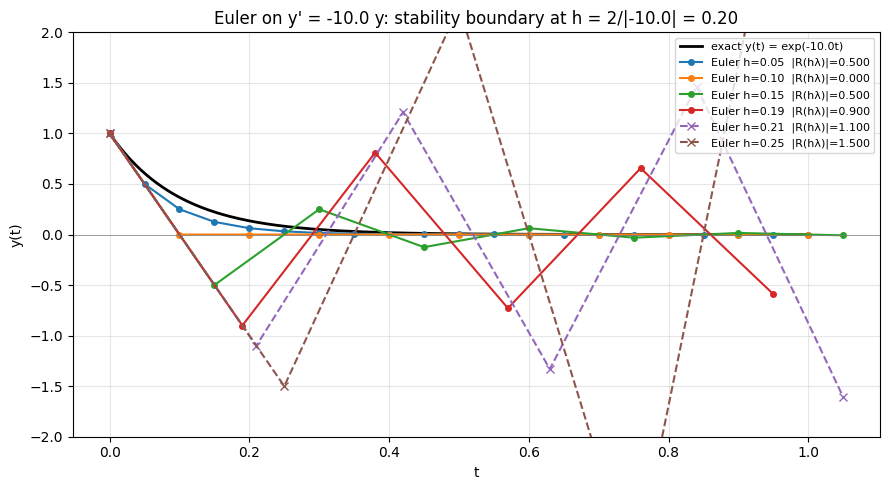

In [2]:
# (b) lambda = -10, 여러 h 로 Euler 적분
def taylor_test(lam, h, T, p):
    n = int(round(T / h))
    z = complex(h * lam)
    R = complex(Rp(z, p))
    y = 1.0 + 0j
    ts = [0.0]
    ys = [y.real]
    for k in range(n):
        y = R * y
        ts.append((k+1)*h)
        ys.append(y.real)
    return np.array(ts), np.array(ys)

lam = -10.0
T = 1.0
hs_test = [0.05, 0.10, 0.15, 0.19, 0.21, 0.25]

fig, ax = plt.subplots(figsize=(9, 5))
t_fine = np.linspace(0, T, 400)
ax.plot(t_fine, np.exp(lam * t_fine), "k-", linewidth=2, label=f"exact y(t) = exp({lam}t)")
for h in hs_test:
    ts, ys = taylor_test(lam, h, T, p=1)
    z = h * lam
    R = float(abs(Rp(complex(z), 1)))
    label = f"Euler h={h:.2f}  |R(hλ)|={R:.3f}"
    if R <= 1.0:
        ax.plot(ts, ys, "o-", markersize=4, label=label)
    else:
        ax.plot(ts, ys, "x--", markersize=6, label=label)
ax.axhline(0, color="gray", linewidth=0.5)
ax.set_xlabel("t")
ax.set_ylabel("y(t)")
ax.set_title(f"Euler on y' = {lam} y: stability boundary at h = 2/|{lam}| = 0.20")
ax.legend(fontsize=8, loc="upper right")
ax.set_ylim(-2, 2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


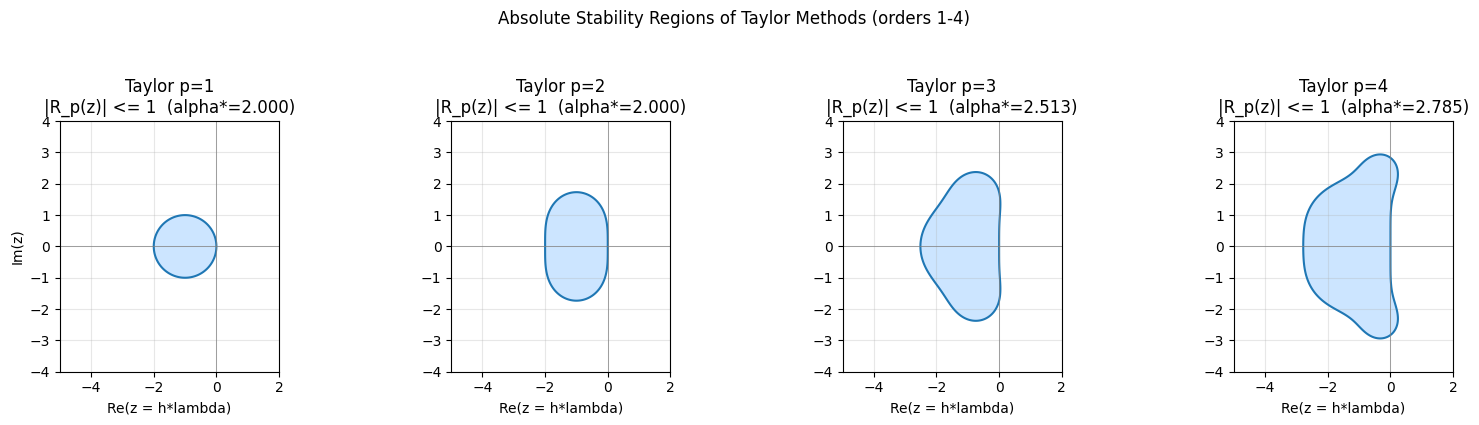

In [3]:
# (c) 복소 평면 안정 영역 등고선 — p = 1..4
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
xx = np.linspace(-5, 2, 400)
yy = np.linspace(-4, 4, 400)
X, Y = np.meshgrid(xx, yy)
Z = X + 1j*Y
for i, p in enumerate([1, 2, 3, 4]):
    absR = np.abs(Rp(Z, p))
    ax = axes[i]
    cf = ax.contourf(X, Y, absR, levels=[0, 1.0], colors=["#cce5ff"])
    ax.contour(X, Y, absR, levels=[1.0], colors="C0", linewidths=1.5)
    ax.axhline(0, color="gray", lw=0.5)
    ax.axvline(0, color="gray", lw=0.5)
    ax.set_title(f"Taylor p={p}\n|R_p(z)| <= 1  (alpha*={limits[p]:.3f})")
    ax.set_xlabel("Re(z = h*lambda)")
    if i == 0:
        ax.set_ylabel("Im(z)")
    ax.set_xlim(-5, 2)
    ax.set_ylim(-4, 4)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)
plt.suptitle("Absolute Stability Regions of Taylor Methods (orders 1-4)", y=1.05)
plt.tight_layout()
plt.show()


In [4]:
# 안정 영역 정량 요약 — lambda = -10, -50, -100 의 최대 허용 h
records = []
for lam_ in [-10, -50, -100]:
    for p in [1, 2, 3, 4]:
        h_max = limits[p] / abs(lam_)
        records.append({"lambda": lam_, "order p": p, "alpha*": limits[p],
                        "h_max = alpha*/|lambda|": h_max,
                        "N_min = T/h_max": int(np.ceil(1.0 / h_max))})
df = pd.DataFrame(records)
df


,lambda,order p,alpha*,h_max = alpha*/|lambda|,N_min = T/h_max
0,-10,1,2.000000,0.200000,5
1,-10,2,2.000000,0.200000,5
2,-10,3,2.512745,0.251275,4
3,-10,4,2.785294,0.278529,4
4,-50,1,2.000000,0.040000,25
5,-50,2,2.000000,0.040000,25
6,-50,3,2.512745,0.050255,20
7,-50,4,2.785294,0.055706,18
8,-100,1,2.000000,0.020000,50
9,-100,2,2.000000,0.020000,50


## 4. 결과 해석

1. **음 실축 한계** ($\alpha_p^\star$): 표에서 $p = 1, 2$ 는 정확히 $2.000$, $p = 3$ 은 $2.513$, $p = 4$ 는
   $2.785$. *고차로 가도* 음 실축 한계는 $40 \%$ 만 늘어난다. $\Rightarrow$ Taylor 법은 *stiffness* 의 답이 아니다.
2. **(b) 시각화**: $\lambda = -10$ 에서 $h \le 0.20$ ($|R| \le 1$) 인 경우 수치해가 *지수 감쇠* 를 따라가지만,
   $h = 0.21$ 또는 $h = 0.25$ 에서는 $|R| > 1$ 이라 *부호가 뒤집히며 폭발* — 진짜 해는 $1$ 보다 한참 작은
   숫자인데 수치해는 발산.
3. **(c) 복소 안정 영역**: $p$ 가 올라가면 *허수축 방향* 으로 영역이 확장 (진동 문제에 유리) 되지만, 음의
   *실축* 방향으로는 별로 늘지 않는다 — *부드러운 감쇠* 문제에 한 차원 더 정확하다고 해서 *더 큰 스텝*
   을 쓸 수 있는 건 아니다.
4. **표 — stiffness 비용**: $\lambda = -100$ 에서 $p = 1$ Euler 는 $h \le 0.02$, 즉 *최소 50 스텝*.
   $p = 4$ 로 올려도 $h \le 0.028$, 36 스텝 — 비용이 *동급*.

> **결론**: Taylor 법의 *수렴 차수* 와 *안정 영역* 은 별개의 다이얼이다. 차수만 올려도 stiffness 문제는
> 풀리지 않는다. *implicit* 방법 (예: backward Euler, BDF) 이 그 답이며, 다음 챕터에서 다룬다.

### 다음 단원으로의 연결
- **§7.2 Runge–Kutta**: 같은 차수의 정확도를 *해석적 도함수 없이* — $f$ 만 여러 번 평가해서 — 얻는다.
  RK4 (4 차 명시) 의 안정 영역은 Taylor 4 와 *거의 동일* 하지만 해석적 미분이 필요 없어 훨씬 실용적.
- **§7.3 적응형 RK + Multistep**: 한 스텝의 *오차 자가 진단* 으로 $h$ 를 동적으로 조절.
- **§7.5 ABM (Adams–Bashforth–Moulton)**: 이전 스텝들을 *재사용* 해 비용을 다시 낮춤.
- 다음 장 (Ch 8): *LU / SVD* — *implicit* 방법이 매 스텝 *비선형 연립* 을 풀어야 하므로 자연스럽게 이어진다.
